In [1]:
! pip install --upgrade -q pandas numpy scikit-learn imbalanced-learn

In [ ]:
import sys
from pathlib import Path

# adiciona a pasta src ao sys.path
SRC_DIR = Path().resolve().parent  # .../src
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

In [ ]:
from collections import Counter

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline

from utils.constants import *

In [3]:
df = pd.read_csv("../data/3_gold/dataset-processed-rf.csv")
X = df.drop("class", axis=1)
y = df["class"]
y = y.map(TARGET_LABEL_MAP)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y
)

X_coarse = X_train.copy()
y_coarse = y_train.copy()
y_coarse = y_coarse.map(COARSE_LABEL_MAP)

high_risk_mask = y_train.isin([1, 2])
X_fine = X_train[high_risk_mask].copy()
y_fine = y_train[high_risk_mask].copy()
y_fine = y_fine.map(FINE_LABEL_MAP)

class_counts_coarse = Counter(y_coarse)
class_counts_fine = Counter(y_fine)

print("=== Coarse Data ===")
for class_idx, count in class_counts_coarse.items():
    print(f"Number of '{TARGET_NAMES_COARSE[class_idx]}' examples: {count}")

print("\n=== Fine Data ===")
for class_idx, count in class_counts_fine.items():
    print(f"Number of '{TARGET_NAMES_FINE[class_idx]}' examples: {count}")

=== Coarse Data ===
Number of 'high_risk' examples: 252418
Number of 'low_risk' examples: 359335

=== Fine Data ===
Number of 'alarm' examples: 228124
Number of 'severe' examples: 24294


In [4]:
params_coarse = {'n_estimators': 100, 'max_depth': 30, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'random_state': RANDOM_STATE}
params_fine = {'n_estimators': 200, 'max_depth': 45, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'random_state': RANDOM_STATE}

def get_pipeline(fine_grained=False):
    steps = []
    if fine_grained:
        steps.append(('under', RandomUnderSampler(sampling_strategy={0: max(class_counts_fine[1], class_counts_fine[0] // 2)}, random_state=RANDOM_STATE)))
        steps.append(('over', SMOTE(sampling_strategy={1: max(class_counts_fine[1], class_counts_fine[0] // 4)}, random_state=RANDOM_STATE)))
        steps.append(('model', RandomForestClassifier(**params_fine)))
    else:
        steps.append(('under', RandomUnderSampler(sampling_strategy={0: class_counts_coarse[1]}, random_state=RANDOM_STATE)))
        steps.append(('model', RandomForestClassifier(**params_coarse)))
    return Pipeline(steps)


def train(X, y, fine_grained=False):
    pipeline = get_pipeline(fine_grained=fine_grained)
    pipeline.fit(X, y)
    return pipeline


def train_and_eval(X_train, X_valid, y_train, y_valid, fine_grained=False):
    pipeline = train(X_train, y_train, fine_grained=fine_grained)
    preds = pipeline.predict(X_valid)
    f1 = f1_score(y_valid, preds, average='macro')
    return f1, preds


def train_on_folds(X, y, fine_grained=False):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for train_idx, valid_idx in skf.split(X, y):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_valid, y_valid = X.iloc[valid_idx], y.iloc[valid_idx]
        try:
            f1 = train_and_eval(X_train, y_train, X_valid, y_valid, fine_grained=fine_grained)
            scores.append(f1)
        except ValueError:
            return 0.0, 1.0

    return np.mean(scores), np.std(scores)


def eval_hierarchical(model_coarse, model_fine, X_val, y_val, threshold=0.35):
    # Predict Coarse (0 = Low, 1 = High)
    probs_coarse = model_coarse.predict_proba(X_val)[:, 1]
    preds_coarse = (probs_coarse >= threshold).astype(int)
    final_preds = preds_coarse.copy()
    
    high_risk_indices = np.where(preds_coarse == 1)[0]
    
    if len(high_risk_indices) > 0:
        X_high_risk = X_val.iloc[high_risk_indices]
        
        # Predict Fine (0 = Alarm, 1 = Severe)
        preds_fine_local = model_fine.predict(X_high_risk)
        
        # Map Fine predictions back to Global labels
        preds_fine_global = np.array([FINE_LABEL_MAP_REVERSE[p] for p in preds_fine_local])
        final_preds[high_risk_indices] = preds_fine_global

    print(classification_report(y_val, final_preds, target_names=["Low Risk", "Alarm", "Severe"]))
    return f1_score(y_val, final_preds, average='macro'), final_preds

In [5]:
pipeline_coarse = get_pipeline(fine_grained=False)
pipeline_coarse.fit(X_coarse, y_coarse)

pipeline_fine = get_pipeline(fine_grained=True)
pipeline_fine.fit(X_fine, y_fine)

f1, preds = eval_hierarchical(pipeline_coarse, pipeline_fine, X_test, y_test)

              precision    recall  f1-score   support

    Low Risk       0.86      0.55      0.67     63413
       Alarm       0.52      0.82      0.64     40257
      Severe       0.27      0.28      0.27      4287

    accuracy                           0.64    107957
   macro avg       0.55      0.55      0.53    107957
weighted avg       0.71      0.64      0.64    107957



In [6]:
! pip install matplotlib

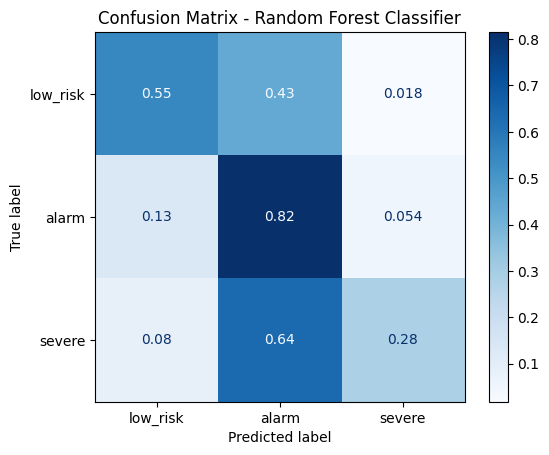

In [7]:
# Plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, preds, display_labels=TARGET_NAMES, cmap=plt.cm.Blues, normalize='true'
)
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()